# Traffic flows – morning, midday, evening, whole day

This notebook:

- Loads traffic flows from a GeoParquet file
- Aggregates hourly flows into:
  - Morning rush
  - Midday / afternoon
  - Evening rush
  - Whole day total
- Plots all four as a 2×2 grid
  - Line width and color both encode flow intensity


In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib as mpl


In [10]:
# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
GEO_PARQUET_PATH = (
    #"/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/AWS/containers/local_bucket/gold/motorized_traffic/2025_new/V2_motorized_traffic_complete_full.parquet"
    "/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/AWS/containers/local_bucket/gold/motorized_traffic/2025_new_model/2025_motorized_traffic_complete_full.parquet"
)

# ------------------------------------------------------------
# Column names – ADAPT to your schema
# ------------------------------------------------------------
HOUR_COL = "hour"   # integer 0–23
FLOW_COL = "total_flow"   # hourly flow per segment

# If you have an edge/segment ID column, set it here, else None
EDGE_ID_COL = None     # or None

# ------------------------------------------------------------
# Time windows (hours of day, 0–23) – ADAPT as you like
# ------------------------------------------------------------
MORNING_HOURS  = list(range(6, 11))     # 06–10
MIDDAY_HOURS   = list(range(11, 16))    # 11–15
EVENING_HOURS  = list(range(16, 21))    # 16–20

# Aggregation function over time window
# "sum" -> total flow, "mean" -> average flow per hour, etc.
AGG_FUNC = "sum"  # or "mean"


In [11]:
gdf = gpd.read_parquet(GEO_PARQUET_PATH)

# Ensure hour is integer
gdf[HOUR_COL] = gdf[HOUR_COL].astype(int)

display(gdf.head())
print(gdf[[HOUR_COL, FLOW_COL]].head())
print(f"CRS: {gdf.crs}")


,edge_id,u,v,key,hour,total_flow,name,length,bearing,geometry,flow_norm
0,2753,74926632,372762234,0,0,22.224231,Seestrasse,627.269,159.0,"LINESTRING (2682894.991 1244190.776, 2682896.3...",0.118040
1,2753,74926632,372762234,0,1,13.822956,Seestrasse,627.269,159.0,"LINESTRING (2682894.991 1244190.776, 2682896.3...",0.105960
2,2753,74926632,372762234,0,2,8.788388,Seestrasse,627.269,159.0,"LINESTRING (2682894.991 1244190.776, 2682896.3...",0.091368
3,2753,74926632,372762234,0,3,6.480851,Seestrasse,627.269,159.0,"LINESTRING (2682894.991 1244190.776, 2682896.3...",0.074641
4,2753,74926632,372762234,0,4,6.616830,Seestrasse,627.269,159.0,"LINESTRING (2682894.991 1244190.776, 2682896.3...",0.063254


   hour  total_flow
0     0   22.224231
1     1   13.822956
2     2    8.788388
3     3    6.480851
4     4    6.616830
CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "ProjectedCRS", "name": "CH1903+ / LV95", "base_crs": {"name": "CH1903+", "datum": {"type": "GeodeticReferenceFrame", "name": "CH1903+", "ellipsoid": {"name": "Bessel 1841", "semi_major_axis": 6377397.155, "inverse_flattening": 299.1528128}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "id": {"authority": "EPSG", "code": 4150}}, "conversion": {"name": "Swiss Oblique Mercator 1995", "method": {"name": "Hotine Oblique Mercator (variant B)", "id": {"authority": "EPSG", "code": 9815}}, "parameters": [{"name": "Latitude of projection centre", "value": 46.9524055555556, "unit": "degree", "id": {"a

In [12]:
def aggregate_for_hours(gdf, hours, hour_col, flow_col, edge_id_col=None,
                        agg_func="sum"):
    """
    Aggregate flows over a set of hours in the day.

    Parameters
    ----------
    gdf : GeoDataFrame
        Input data with hourly flows per segment.
    hours : list[int]
        List of hours of day (0–23) to include.
    hour_col : str
        Name of the hour column (0–23).
    flow_col : str
        Name of flow column.
    edge_id_col : str or None
        Column identifying road segments. If None, geometry is used as key.
    agg_func : str
        Aggregation function: "sum", "mean", ...

    Returns
    -------
    GeoDataFrame with one row per segment and aggregated flow.
    """
    # Filter for selected hours
    mask = gdf[hour_col].isin(hours)
    subset = gdf.loc[mask].copy()
    if subset.empty:
        raise ValueError(f"No rows found for hours {hours}")

    if agg_func == "sum":
        agg_dict = {flow_col: "sum"}
    else:
        agg_dict = {flow_col: agg_func}

    if edge_id_col is not None and edge_id_col in subset.columns:
        grouped = (
            subset
            .groupby(edge_id_col)
            .agg({flow_col: agg_func, "geometry": "first"})
            .reset_index()
        )
        result = gpd.GeoDataFrame(grouped, geometry="geometry", crs=gdf.crs)
    else:
        grouped = (
            subset
            .groupby("geometry", as_index=False)
            .agg(agg_dict)
        )
        result = gpd.GeoDataFrame(grouped, geometry="geometry", crs=gdf.crs)

    return result


In [13]:
# Morning
gdf_morning = aggregate_for_hours(
    gdf,
    hours=MORNING_HOURS,
    hour_col=HOUR_COL,
    flow_col=FLOW_COL,
    edge_id_col=EDGE_ID_COL,
    agg_func=AGG_FUNC,
)

# Midday / afternoon
gdf_midday = aggregate_for_hours(
    gdf,
    hours=MIDDAY_HOURS,
    hour_col=HOUR_COL,
    flow_col=FLOW_COL,
    edge_id_col=EDGE_ID_COL,
    agg_func=AGG_FUNC,
)

# Evening
gdf_evening = aggregate_for_hours(
    gdf,
    hours=EVENING_HOURS,
    hour_col=HOUR_COL,
    flow_col=FLOW_COL,
    edge_id_col=EDGE_ID_COL,
    agg_func=AGG_FUNC,
)

# Whole day (all hours present)
all_hours = sorted(gdf[HOUR_COL].unique())
gdf_whole_day = aggregate_for_hours(
    gdf,
    hours=all_hours,
    hour_col=HOUR_COL,
    flow_col=FLOW_COL,
    edge_id_col=EDGE_ID_COL,
    agg_func=AGG_FUNC,
)

for label, gdf_agg in [
    ("Morning", gdf_morning),
    ("Midday", gdf_midday),
    ("Evening", gdf_evening),
    ("Whole day", gdf_whole_day),
]:
    print(
        f"{label}: {len(gdf_agg)} segments, "
        f"{FLOW_COL} ∈ [{gdf_agg[FLOW_COL].min():.1f}, {gdf_agg[FLOW_COL].max():.1f}]"
    )


Morning: 5936 segments, total_flow ∈ [0.0, 2429.6]
Midday: 6048 segments, total_flow ∈ [0.0, 2835.9]
Evening: 6211 segments, total_flow ∈ [0.0, 3004.5]
Whole day: 6253 segments, total_flow ∈ [0.0, 9448.7]


In [14]:
all_flows = pd.concat([
    gdf_morning[FLOW_COL],
    gdf_midday[FLOW_COL],
    gdf_evening[FLOW_COL],
    gdf_whole_day[FLOW_COL],
])

max_flow = all_flows.max()
min_flow = all_flows.min()

print(f"Global {FLOW_COL} range across all periods: {min_flow:.2f} – {max_flow:.2f}")

norm = Normalize(vmin=0, vmax=max_flow)
cmap = plt.cm.viridis

BASE_LW = 0.2      # minimum linewidth
MAX_EXTRA_LW = 3.0  # added for max flow


Global total_flow range across all periods: 0.00 – 9448.66


/var/folders/dz/xk92rf811x11gfspml0l9cdr0000gn/T/ipykernel_47984/1438452823.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


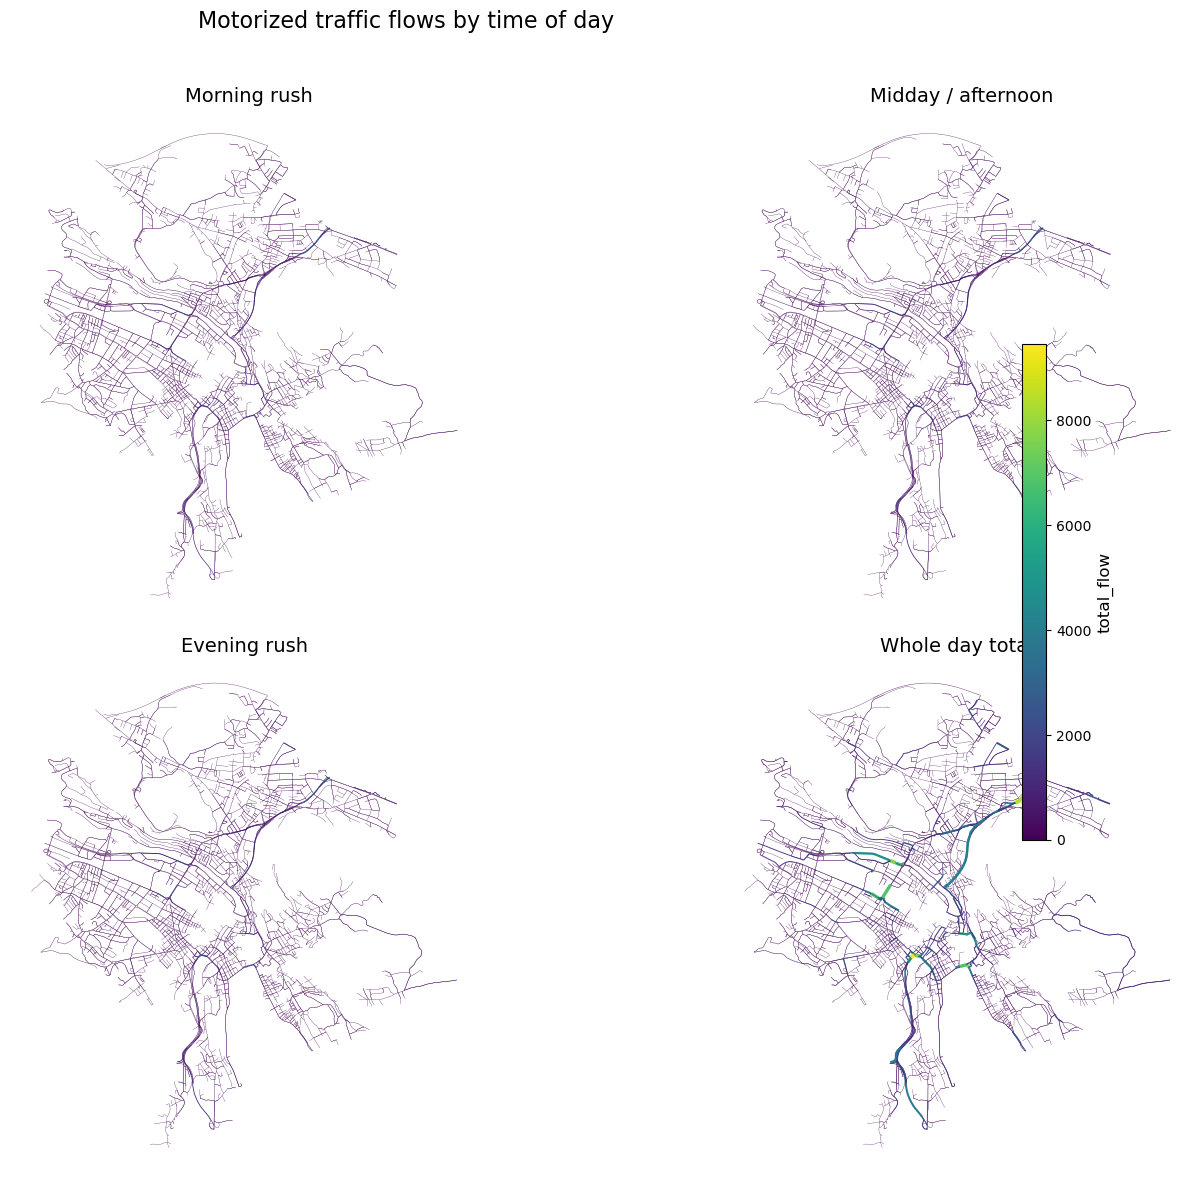

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

periods = [
    ("Morning rush", gdf_morning),
    ("Midday / afternoon", gdf_midday),
    ("Evening rush", gdf_evening),
    ("Whole day total", gdf_whole_day),
]

for ax, (title, gdf_agg) in zip(axes.flat, periods):
    # Per-row linewidths
    lw = BASE_LW + MAX_EXTRA_LW * (gdf_agg[FLOW_COL] / max_flow)

    # Map flow to RGBA colors
    colors = cmap(norm(gdf_agg[FLOW_COL].values))

    gdf_agg.plot(
        ax=ax,
        color=colors,
        linewidth=lw,
    )

    ax.set_title(title, fontsize=14)
    ax.set_axis_off()
    ax.set_aspect("equal")

# Shared colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes.ravel().tolist(),
    fraction=0.02,
    pad=0.01
)
cbar.set_label(FLOW_COL, fontsize=12)

plt.suptitle("Motorized traffic flows by time of day", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [16]:
# Recompute scaling ONLY from the three aggregated rush-hour GeoDataFrames

flows_3 = pd.concat([
    gdf_morning[FLOW_COL],
    gdf_midday[FLOW_COL],
    gdf_evening[FLOW_COL],
])

max_flow_3 = flows_3.max()
min_flow_3 = flows_3.min()

print(f"Rush-hour {FLOW_COL} range (3 periods): {min_flow_3:.2f} – {max_flow_3:.2f}")

# New normalization + colormap for these 3 plots
norm_3 = Normalize(vmin=0, vmax=max_flow_3)
cmap_3 = plt.cm.viridis

# Optionally reuse your old values or tweak for these specific plots
BASE_LW_3 = 0.2       # minimum linewidth
MAX_EXTRA_LW_3 = 2.0  # extra linewidth at max flow


Rush-hour total_flow range (3 periods): 0.00 – 3004.49


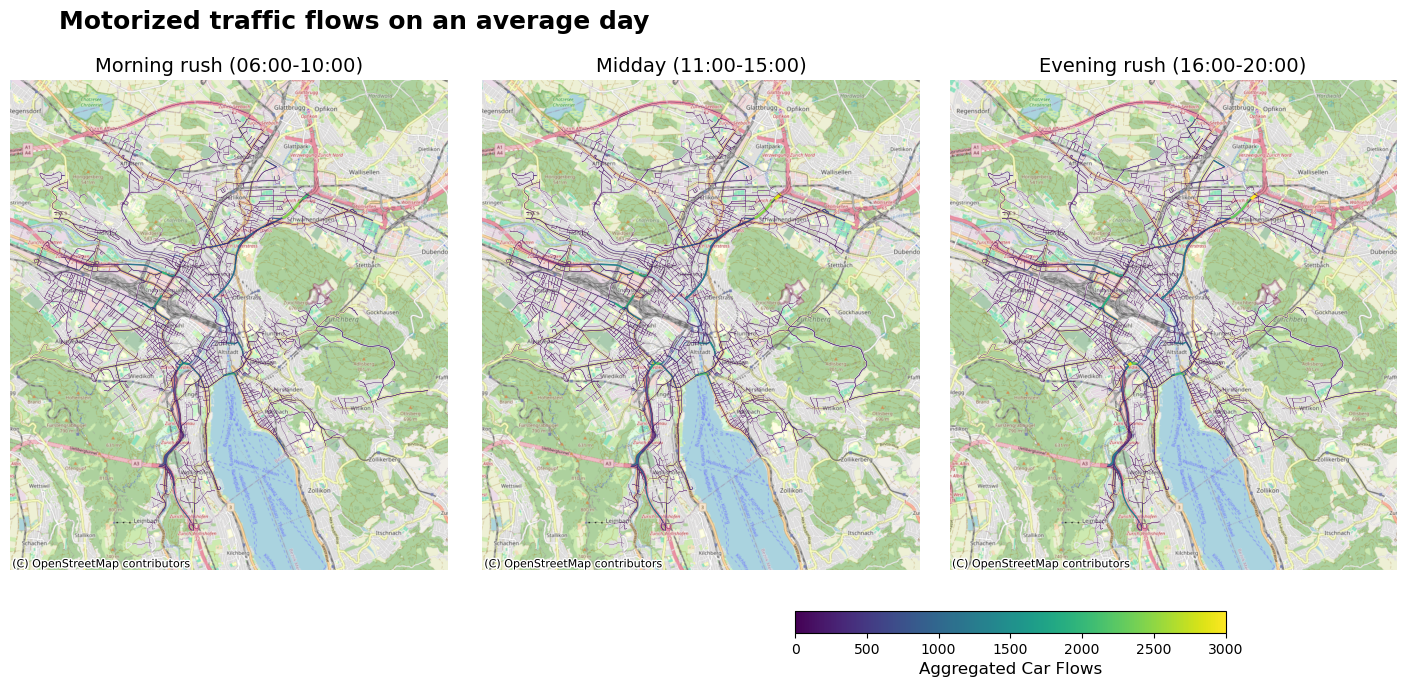

In [17]:
import contextily as ctx
import matplotlib as mpl

# Reproject to Web Mercator (if not already)
gdf_morning_3857 = gdf_morning.to_crs(epsg=3857)
gdf_midday_3857  = gdf_midday.to_crs(epsg=3857)
gdf_evening_3857 = gdf_evening.to_crs(epsg=3857)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

periods_3857 = [
    ("Morning rush (06:00-10:00)", gdf_morning_3857),
    ("Midday (11:00-15:00)", gdf_midday_3857),
    ("Evening rush (16:00-20:00)", gdf_evening_3857),
]

for ax, (title, gdf_agg) in zip(axes.flat, periods_3857):
    # Line widths based on *new* scale
    lw = BASE_LW_3 + MAX_EXTRA_LW_3 * (gdf_agg[FLOW_COL] / max_flow_3)

    # Colors based on *new* norm_3
    colors = cmap_3(norm_3(gdf_agg[FLOW_COL].values))

    # Plot flows
    gdf_agg.plot(
        ax=ax,
        color=colors,
        linewidth=lw,
        zorder=2,
    )

    # Add OSM basemap
    ctx.add_basemap(
        ax,
        source=ctx.providers.OpenStreetMap.Mapnik,
        crs=gdf_agg.crs,
        zorder=1,
    )

    ax.set_title(title, fontsize=14)
    ax.set_axis_off()
    ax.set_aspect("equal")

# Shared colorbar for the 3 plots, using norm_3 / cmap_3
sm = mpl.cm.ScalarMappable(norm=norm_3, cmap=cmap_3)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    fraction=0.04,
    pad=0.08,
)
cbar.set_label("Aggregated Car Flows", fontsize=12)

# Tighter spacing between maps
plt.subplots_adjust(
    left=0.03,
    right=0.7,
    top=0.90,
    bottom=0.2,
    wspace=0.02,
)

plt.suptitle(
    "Motorized traffic flows on an average day",
    fontsize=18,
    fontweight="bold",
    y=1,
    x=0.2
)

plt.show()
